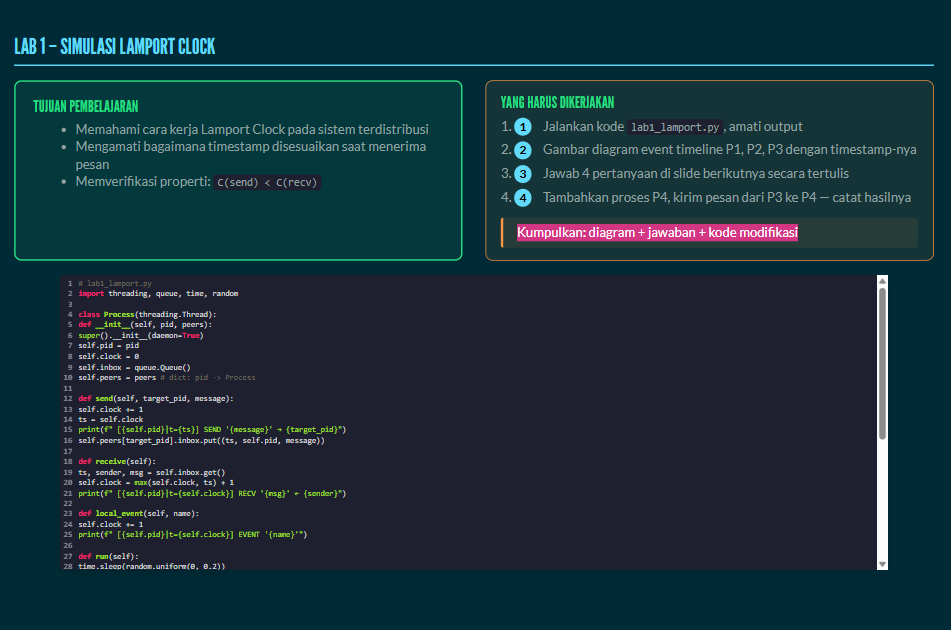  

<p>Algoritma timestamp Lamport adalah algoritma jam logis sederhana yang digunakan untuk menentukan urutan kejadian dalam sistem komputer terdistribusi. Karena node atau proses yang berbeda biasanya tidak tersinkronisasi secara sempurna, algoritma ini digunakan untuk memberikan pengurutan sebagian (<i>partial ordering</i>) dari kejadian dengan beban (<i>overhead</i>) yang minimal, serta secara konsep menjadi dasar awal untuk metode yang lebih canggih yaitu vector clock.</p>

Sumber : <a href="https://en.wikipedia.org/wiki/Lamport_timestamp">wikipedia.org</a>

- <a href="https://www.geeksforgeeks.org/dsa/lamports-logical-clock/">Lamport's logical clock</a> adalah sebuah prosedur untuk menentukan urutan kejadian yang terjadi.

$$
\underset{\text{“Nilai clock saat pesan dikirim harus lebih kecil dari pada nilai clock saat pesan diterima.”}}{C_(\text{send}) < C(\text{recv})}
$$

In [1]:
# lab1_lamport.py
import threading, queue, time, random
class Process(threading.Thread):
    def __init__(self, pid, peers):
        super().__init__(daemon=True)
        self.pid = pid
        self.clock = 0
        self.inbox = queue.Queue()
        self.peers = peers # dict: pid -> Process
    
    def send(self, target_pid, message):
        self.clock += 1
        ts = self.clock
        print(f" [{self.pid}|t={ts}] SEND '{message}' → {target_pid}")
        self.peers[target_pid].inbox.put((ts, self.pid, message))
        
    def receive(self):
        ts, sender, msg = self.inbox.get()
        self.clock = max(self.clock, ts) + 1
        print(f" [{self.pid}|t={self.clock}] RECV '{msg}' ← {sender}")

    def local_event(self, name):
        self.clock += 1
        print(f" [{self.pid}|t={self.clock}] EVENT '{name}'")
 
    def run(self):
        time.sleep(random.uniform(0, 0.2))
        if self.pid == "P1":
            self.local_event("start")
            self.send("P2", "hello")
            self.receive() # will get from P2
        elif self.pid == "P2":
            self.receive() # dari P1
            self.local_event("process")
            self.send("P1", "ack")
            self.send("P3", "data")
        elif self.pid == "P3":
            self.receive() # dari P2
            self.local_event("done")
    
processes = {}
for pid in ["P1", "P2", "P3"]:
    processes[pid] = Process(pid, processes)
print("=== Jalankan simulasi Lamport Clock ===")
for p in processes.values(): p.start()
for p in processes.values(): p.join(timeout=3)
print("=== Selesai ===")

=== Jalankan simulasi Lamport Clock ===
 [P1|t=1] EVENT 'start'
 [P1|t=2] SEND 'hello' → P2
 [P2|t=3] RECV 'hello' ← P1
 [P2|t=4] EVENT 'process'
 [P2|t=5] SEND 'ack' → P1
 [P2|t=6] SEND 'data' → P3
 [P1|t=6] RECV 'ack' ← P2
 [P3|t=7] RECV 'data' ← P2
 [P3|t=8] EVENT 'done'
=== Selesai ===


## Diagram Event

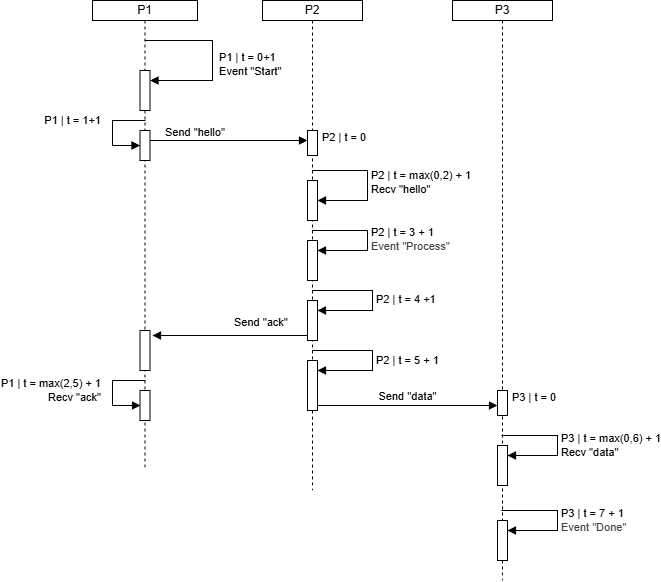

### Penambahan (P4)

Pada bagian ini, proses **P4** ditambahkan ke dalam simulasi Lamport Clock. Rantai komunikasi diperpanjang menjadi **P1 → P2 → P3 → P4**, di mana:

- **P1** melakukan event lokal `"start"`, mengirim `"hello"` ke P2, lalu menunggu `"ack"` dari P2.
- **P2** menerima dari P1, melakukan event lokal `"process"`, mengirim `"ack"` ke P1 dan `"data"` ke P3, lalu menunggu balasan dari P3.
- **P3** menerima dari P2, melakukan event lokal `"process"`, mengirim `"ack"` ke P2 dan `"data"` ke P4.
- **P4** menerima dari P3 dan melakukan event lokal `"done"`.

Ini memperlihatkan bagaimana Lamport Clock menjaga aturan *happened-before* sepanjang rantai proses yang lebih panjang: $C(\text{send}) < C(\text{recv})$ tetap berlaku di setiap hop.

In [2]:
# lab1_lamport.py
import threading, queue, time, random
class Process(threading.Thread):
    def __init__(self, pid, peers):
        super().__init__(daemon=True)
        self.pid = pid
        self.clock = 0
        self.inbox = queue.Queue()
        self.peers = peers # dict: pid -> Process
    
    def send(self, target_pid, message):
        self.clock += 1
        ts = self.clock
        print(f" [{self.pid}|t={ts}] SEND '{message}' → {target_pid}")
        self.peers[target_pid].inbox.put((ts, self.pid, message))
        
    def receive(self):
        ts, sender, msg = self.inbox.get()
        self.clock = max(self.clock, ts) + 1
        print(f" [{self.pid}|t={self.clock}] RECV '{msg}' ← {sender}")

    def local_event(self, name):
        self.clock += 1
        print(f" [{self.pid}|t={self.clock}] EVENT '{name}'")
 
    def run(self):
        time.sleep(random.uniform(0, 0.2))
        if self.pid == "P1":
            self.local_event("start")
            self.send("P2", "hello")
            self.receive() # will get from P2
        elif self.pid == "P2":
            self.receive() # dari P1
            self.local_event("process")
            self.send("P1", "ack")
            self.send("P3", "data")
            self.receive() # will get from P3
        elif self.pid == "P3":
            self.receive() # dari P2
            self.local_event("process")
            self.send("P2", "ack")
            self.send("P4", "data")
        elif self.pid == "P4":
            self.receive() # dari P3
            self.local_event("done")
processes = {}
for pid in ["P1", "P2", "P3", "P4"]:
    processes[pid] = Process(pid, processes)
print("=== Jalankan simulasi Lamport Clock ===")
for p in processes.values(): p.start()
for p in processes.values(): p.join(timeout=3)
print("=== Selesai ===")

=== Jalankan simulasi Lamport Clock ===
 [P1|t=1] EVENT 'start'
 [P1|t=2] SEND 'hello' → P2
 [P2|t=3] RECV 'hello' ← P1
 [P2|t=4] EVENT 'process'
 [P2|t=5] SEND 'ack' → P1
 [P2|t=6] SEND 'data' → P3
 [P1|t=6] RECV 'ack' ← P2
 [P3|t=7] RECV 'data' ← P2
 [P3|t=8] EVENT 'process'
 [P3|t=9] SEND 'ack' → P2
 [P3|t=10] SEND 'data' → P4
 [P2|t=10] RECV 'ack' ← P3
 [P4|t=11] RECV 'data' ← P3
 [P4|t=12] EVENT 'done'
=== Selesai ===


## Algoritma Vector Clock

**Vector Clock** adalah pengembangan dari Lamport Clock. Setiap proses menyimpan sebuah vektor berukuran $n$ (jumlah proses), sehingga urutan kausal dapat dideteksi secara penuh — termasuk kejadian *concurrent* yang tidak bisa dibedakan oleh Lamport Clock.

**Aturan:**
- Sebelum event lokal atau mengirim pesan: `clock[self] += 1`
- Saat menerima pesan dengan timestamp $T$: `clock[p] = max(clock[p], T[p])` untuk semua $p$, lalu `clock[self] += 1`

**Relasi:**
$$
\vec{a} \to \vec{b} \iff \forall p,\ \vec{a}[p] \le \vec{b}[p]\ \wedge\ \exists p,\ \vec{a}[p] < \vec{b}[p]
$$
Jika $\vec{a} \not\to \vec{b}$ dan $\vec{b} \not\to \vec{a}$, maka kedua kejadian **concurrent** ($\vec{a} \parallel \vec{b}$).

In [3]:
# vector_clock.py
import threading, queue, time, random

class VCProcess(threading.Thread):
    def __init__(self, pid, all_pids, peers):
        super().__init__(daemon=True)
        self.pid = pid
        self.clock = {p: 0 for p in all_pids}
        self.inbox = queue.Queue()
        self.peers = peers  # dict: pid -> VCProcess

    def _tick(self):
        self.clock[self.pid] += 1

    def _merge(self, remote_ts):
        for p in self.clock:
            self.clock[p] = max(self.clock[p], remote_ts[p])
        self.clock[self.pid] += 1

    def local_event(self, name):
        self._tick()
        print(f" [{self.pid}|{dict(self.clock)}] EVENT '{name}'")

    def send(self, target_pid, message):
        self._tick()
        ts = dict(self.clock)
        print(f" [{self.pid}|{ts}] SEND '{message}' → {target_pid}")
        self.peers[target_pid].inbox.put((ts, self.pid, message))

    def receive(self):
        ts, sender, msg = self.inbox.get()
        self._merge(ts)
        print(f" [{self.pid}|{dict(self.clock)}] RECV '{msg}' ← {sender}")

    def run(self):
        time.sleep(random.uniform(0, 0.2))
        if self.pid == "P1":
            self.local_event("start")
            self.send("P2", "hello")
            self.receive()           # ack dari P2
        elif self.pid == "P2":
            self.receive()           # dari P1
            self.local_event("process")
            self.send("P1", "ack")
            self.send("P3", "data")
        elif self.pid == "P3":
            self.receive()           # dari P2
            self.local_event("done")

pids = ["P1", "P2", "P3"]
vc_processes = {}
for pid in pids:
    vc_processes[pid] = VCProcess(pid, pids, vc_processes)

print("=== Simulasi Vector Clock ===")
for p in vc_processes.values(): p.start()
for p in vc_processes.values(): p.join(timeout=3)
print("=== Selesai ===")


=== Simulasi Vector Clock ===
 [P1|{'P1': 1, 'P2': 0, 'P3': 0}] EVENT 'start'
 [P1|{'P1': 2, 'P2': 0, 'P3': 0}] SEND 'hello' → P2
 [P2|{'P1': 2, 'P2': 1, 'P3': 0}] RECV 'hello' ← P1
 [P2|{'P1': 2, 'P2': 2, 'P3': 0}] EVENT 'process'
 [P2|{'P1': 2, 'P2': 3, 'P3': 0}] SEND 'ack' → P1
 [P2|{'P1': 2, 'P2': 4, 'P3': 0}] SEND 'data' → P3
 [P1|{'P1': 3, 'P2': 3, 'P3': 0}] RECV 'ack' ← P2
 [P3|{'P1': 2, 'P2': 4, 'P3': 1}] RECV 'data' ← P2
 [P3|{'P1': 2, 'P2': 4, 'P3': 2}] EVENT 'done'
=== Selesai ===


### Analisi Output 

#### Lab 1.1
- Dalam Lamport, yang dilihat adalah <i><b>happened-before relation.</b></i>
$$
\underset{\text{"Nilai clock saat pesan dikirim harus lebih kecil dari pada nilai clock saat pesan diterima."}}{C(\text{send}) < C(\text{recv})}
$$ 
- Saat diterima, penerima menghitung dengan rumus: 
$$
{C_j = \max(C_j, T_{\text{msg}}) + 1}
$$ 
<div align="center">
  <pre><code>self.clock = max(self.clock, ts) + 1</code></pre>
</div>
Artinya, proses penerima akan membandingkan clock lokalnya dengan timestamp pesan yang datang, mengambil nilai yang lebih besar, lalu menambah 1. Karena ada +1, maka nilai receive pasti lebih besar dari nilai send pesan tersebut. 

- Hasil receive pasti lebih besar dari timestamp pesan 
- Ini menjaga urutan sebab-akibat bahwa kirim harus terjadi sebelum terima

#### Lab 1.2 — Penambahan P4
Menambahkan P4 memperpanjang rantai *happened-before* menjadi **P1 → P2 → P3 → P4**:

- Clock P4 mewarisi seluruh riwayat kausal dari P1, P2, dan P3 — nilai timestamp P4 pasti lebih besar dari semua timestamp sebelumnya di rantai tersebut.
- Aturan Lamport tetap terjaga di setiap hop: $C(\text{send}) < C(\text{recv})$.
- P2 kini juga menerima balasan `"ack"` dari P3, sehingga clock P2 ikut diperbarui setelah menerima pesan tersebut.
- Semakin panjang rantai proses, semakin tinggi nilai timestamp akhir — ini mencerminkan kedalaman kausal (*causal depth*) dari kejadian.

#### Lab 1.3
- dilihat Dari digaram event, P3 tidak akan menerima data dari P2.
- clock P3 tidak berubah karena pesan itu tidak pernah sampai, Dalam Lamport Clock, clock suatu proses hanya berubah jika proses itu mengalami event lokal, mengirim pesan, atau menerima pesan. Karena pada kasus ini P3 tidak menerima apa-apa dari P2, maka tidak ada alasan bagi clock P3 untuk bertambah.


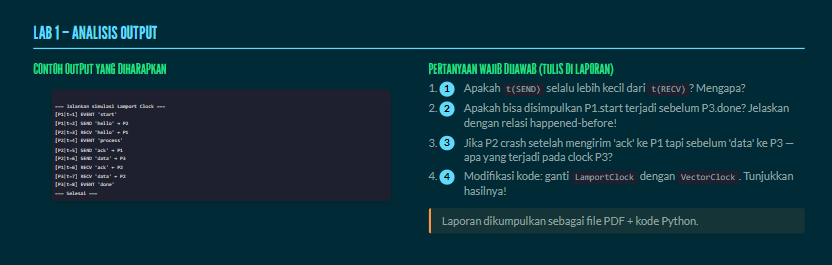

#### Lab 2.1 

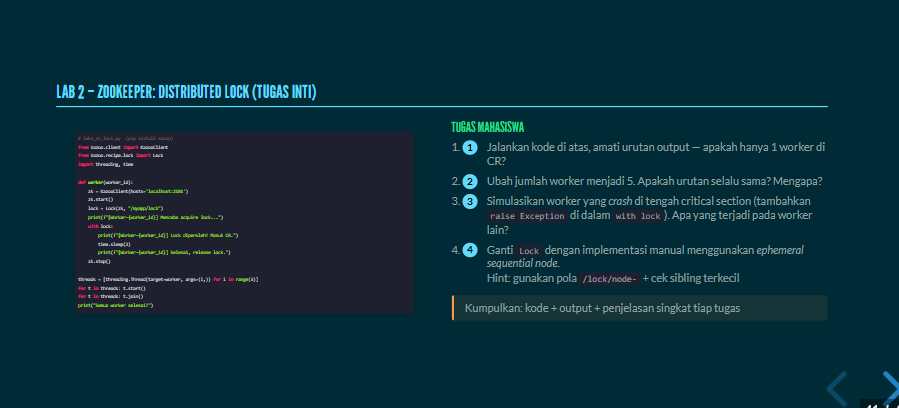

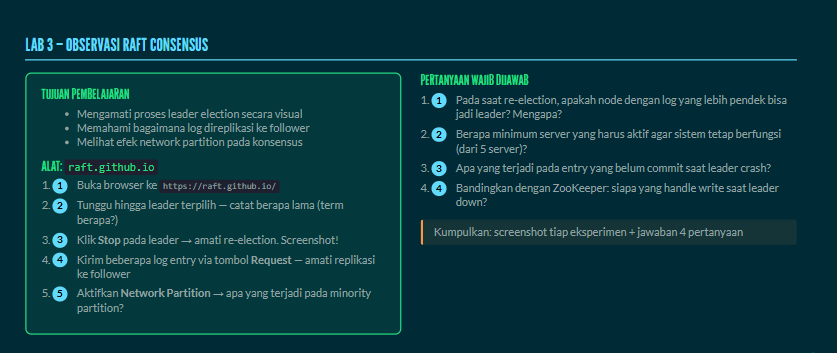 

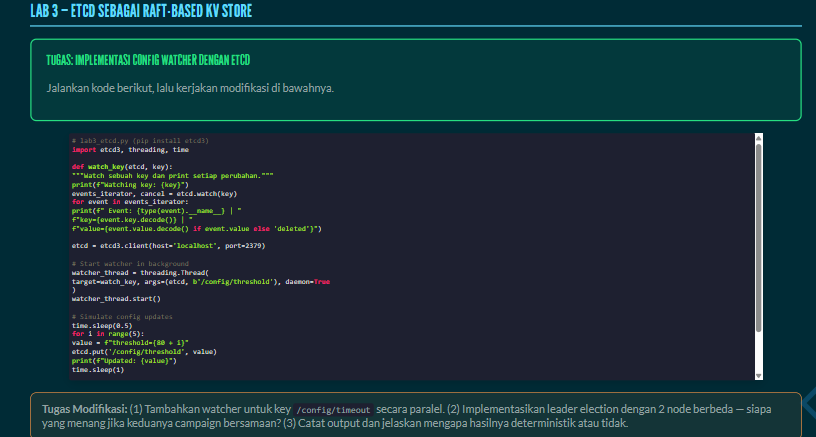 

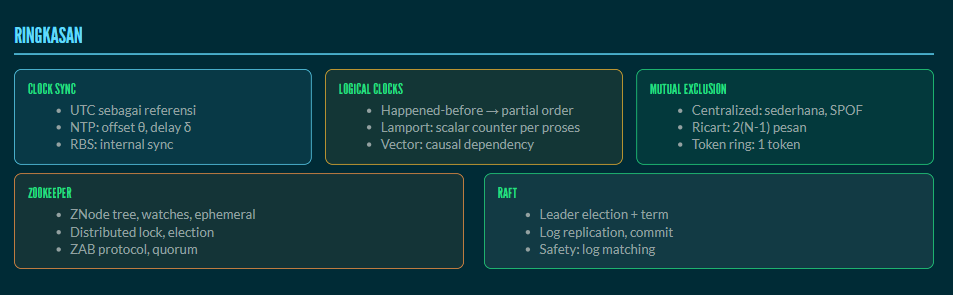

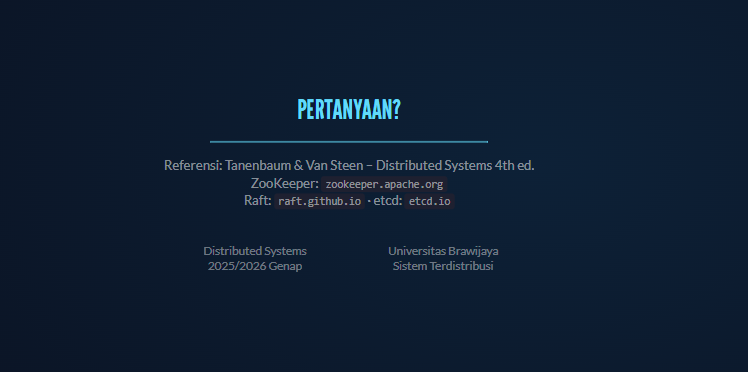